# CatBoost training and testing

### 1. Introduction


In this notebook, we are going to test and try a CatBoost model.

### 2. Librairies


In [4]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc


### 3. Load Data, Filter and Pivot to Wide

In [5]:
# 1 : Load
df_long = pd.read_csv('../../Data/dataREanonymized_long.csv')

# 2 : Finding the subjects with non-null discharge_mrs values
valid_subjects = df_long[
    (df_long['variable'] == 'discharge_mrs') &
    (df_long['Value'].notna())
]['subject_id'].unique()

# 3 : Filter the DataFrame to only include valid subjects
df_long_filtered = df_long[df_long['subject_id'].isin(valid_subjects)]

# 4 : Pivot to Wide format
df_wide = df_long_filtered.pivot(index='subject_id', columns='variable', values='Value').reset_index()

# 5 : Keep only rows where stroke_type is "ischemic"
df_wide = df_wide[df_wide['stroke_type'] == 'ischemic']
df_wide = df_wide[df_wide['thrombolysis'] == '1']


C:\Users\2432741\AppData\Local\Temp\ipykernel_23324\1530815583.py:2: DtypeWarning: Columns (0: Value) have mixed types. Specify dtype option on import or set low_memory=False.
  df_long = pd.read_csv('../../Data/dataREanonymized_long.csv')


### 4. Features

In [6]:
# ==========================================
# Creation of a new feature: anticoagulants_discharge
# ==========================================

anticoagulants_during_discharge =  ['discharge_apixaban', 'discharge_dabigatran', 'discharge_edoxaban', 'discharge_rivaroxaban', 'discharge_warfarin', 'discharge_heparin']

df_wide['anticoagulant_discharge'] = df_wide[anticoagulants_during_discharge].max(axis=1)

df_wide = df_wide.drop(columns=anticoagulants_during_discharge)

In [7]:
# ==========================================
# Creation of a new feature: anticoagulants_before_onset
# ==========================================

anticoagulants_before_onset =  ['before_onset_warfarin']

df_wide['anticoagulant_before_onset'] = df_wide[anticoagulants_before_onset].max(axis=1)

df_wide = df_wide.drop(columns=anticoagulants_before_onset)

In [8]:
# ==========================================
# NIHSS : Three categories: (1) NIHSS<6, (2) 6≤NIHSS<16, (3) NIHSS≥16
# ==========================================

df_wide['nihss_score'] = pd.to_numeric(df_wide['nihss_score'], errors='coerce')

limits = [-np.inf, 6, 16, np.inf]
label = [0, 1, 2]

df_wide['nihss_score'] = pd.cut( df_wide['nihss_score'], bins=limits, labels=label, right=False)

df_wide['nihss_score'] = pd.to_numeric(df_wide['nihss_score'],) 

In [9]:
# ==========================================
# Systolic Blood Pressure (SBP, mmHg) 
# Patients treated with IVT and/or EVT
# Three categories: (1) SBP≤110, (2) 110<SBP<180, (3) SBP≥180
# ==========================================

df_wide['sys_blood_pressure'] = pd.to_numeric(df_wide['sys_blood_pressure'], errors='coerce')

limits = [-np.inf, 111, 180, np.inf]
label = [0, 1, 2]

df_wide['sys_blood_pressure'] = pd.cut( df_wide['sys_blood_pressure'], bins=limits, labels=label, right=False)

df_wide['sys_blood_pressure'] = pd.to_numeric(df_wide['sys_blood_pressure'])

In [10]:
# ==========================================
# Diastolic Blood Pressure (DBP, mmHg) 
# Patients treated with IVT and/or EVT
# Two categories: (1) DBP<105, (2) DBP≥105
# ==========================================

df_wide['dis_blood_pressure'] = pd.to_numeric(df_wide['dis_blood_pressure'], errors='coerce')

limits = [-np.inf, 105, np.inf]
label = [0, 1]

df_wide['dis_blood_pressure'] = pd.cut( df_wide['dis_blood_pressure'], bins=limits, labels=label, right=False)

df_wide['dis_blood_pressure'] = pd.to_numeric(df_wide['dis_blood_pressure'])

In [11]:
# ==========================================
# Blood glucose (mg/dl)
# Three categories: (1) glucose<60, (2) 60≤glucose≤140, (3) glucose>140 
# ==========================================

df_wide['glucose'] = pd.to_numeric(df_wide['glucose'], errors='coerce')

limits = [-np.inf, 60, 141, np.inf]
label = [0, 1, 2]

df_wide['glucose'] = pd.cut( df_wide['glucose'], bins=limits, labels=label, right=False)

df_wide['glucose'] = pd.to_numeric(df_wide['glucose'])

In [12]:
# ==========================================
# Cholesterol (LDL-C, mg/dl)
# Three categories: (1) LDL-C<70, (2) 70≤LDL-C≤100, (3) LDL-C>100
# ==========================================

df_wide['cholesterol'] = pd.to_numeric(df_wide['cholesterol'], errors='coerce')

limits = [-np.inf, 70, 101, np.inf]
label = [0, 1, 2]

df_wide['cholesterol'] = pd.cut( df_wide['cholesterol'], bins=limits, labels=label, right=False)

df_wide['cholesterol'] = pd.to_numeric(df_wide['cholesterol'])

In [13]:
# ==========================================
# Prestroke mRS
# Three categories: (1) 0≤mRS<2, (2) mRS=2, (3) 2<mRS≤5 
# ==========================================

df_wide['prestroke_mrs'] = pd.to_numeric(df_wide['prestroke_mrs'], errors='coerce')

limits = [-np.inf, 2, 3, np.inf]
label = [0, 1, 2]

df_wide['prestroke_mrs'] = pd.cut( df_wide['prestroke_mrs'], bins=limits, labels=label, right=False)

df_wide['prestroke_mrs'] = pd.to_numeric(df_wide['prestroke_mrs'])

In [14]:
# ==========================================
# Onset to door (OTD, hours)
# Patients treated with only IVT
# Three categories: (1) OTD≤4.5, (2) 4.5<OTD≤24, (3) OTD>24  
# ==========================================

df_wide['onset_to_door'] = pd.to_numeric(df_wide['onset_to_door'], errors='coerce')

limits = [-np.inf, 4.5, 24, np.inf]
label = [0, 1, 2]

df_wide['onset_to_door'] = pd.cut( df_wide['onset_to_door'], bins=limits, labels=label, right=True)

df_wide['onset_to_door'] = pd.to_numeric(df_wide['onset_to_door'])

In [15]:
# ==========================================
# Door to imaging (DTI, minutes)
# Two categories: (1) DTI≤20, (2) DTI>20
# ==========================================

df_wide['door_to_imaging'] = pd.to_numeric(df_wide['door_to_imaging'], errors='coerce')

limits = [-np.inf, 20, np.inf]
label = [0, 1]

df_wide['door_to_imaging'] = pd.cut( df_wide['door_to_imaging'], bins=limits, labels=label, right=True)

df_wide['door_to_imaging'] = pd.to_numeric(df_wide['door_to_imaging'])

In [16]:
# ==========================================
# Door to needle (DTN, minutes)
# Four categories: (1) DTN≤30, (2) 30<DTN≤45, (3) 45<DTN≤60, (4) DTN>60
# ==========================================

df_wide['door_to_needle'] = pd.to_numeric(df_wide['door_to_needle'], errors='coerce')

limits = [-np.inf, 30, 45, 60, np.inf]
label = [0, 1, 2, 3]

df_wide['door_to_needle'] = pd.cut( df_wide['door_to_needle'], bins=limits, labels=label, right=True)

df_wide['door_to_needle'] = pd.to_numeric(df_wide['door_to_needle'])

### 5. Target

In [17]:
target_raw = pd.to_numeric(df_wide['three_m_mrs'], errors='coerce')
valid_target = target_raw.notna()

y = (target_raw[valid_target] <= 2).astype(int)

colonnes_a_jeter = ['discharge_mrs', 'three_m_mrs', 'stroke_type', 'thrombolysis']
X = df_wide.loc[valid_target].drop(columns=[col for col in colonnes_a_jeter if col in df_wide.columns])

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.dropna(how='all', axis=1)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

### 6. Train

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_candidates = [
    'nihss_score',
    'sys_blood_pressure',
    'dis_blood_pressure',
    'glucose',
    'cholesterol',
    'prestroke_mrs',
    'onset_to_door',
    'door_to_imaging',
    'door_to_needle',
    'anticoagulant_discharge',
    'anticoagulant_before_onset'
]
cat_features_valides = [col for col in categorical_candidates if col in X_train.columns]
num_features = [col for col in X_train.columns if col not in cat_features_valides]

### 7. Imputing

In [19]:
imputer = KNNImputer(n_neighbors=5)

X_train_num_imputed = pd.DataFrame(
    imputer.fit_transform(X_train[num_features]), 
    columns=num_features, 
    index=X_train.index
)
X_test_num_imputed = pd.DataFrame(
    imputer.transform(X_test[num_features]), 
    columns=num_features, 
    index=X_test.index
)

In [20]:
for col in cat_features_valides:
    X_train_num_imputed[col] = X_train[col].fillna(-1).astype(int)
    X_test_num_imputed[col] = X_test[col].fillna(-1).astype(int)

X_train = X_train_num_imputed
X_test = X_test_num_imputed

In [21]:
# 1. Grille de recherche pour trouver les meilleurs réglages du modèle
param_grid = {
    'iterations': [200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8]
}

In [22]:
# 2. Initialisation du modèle 
cb_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

# 3. Entraînement avec recherche des meilleurs paramètres et validation croisée
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    # estimator=cb_model, 
    # param_distributions=param_grid, 
    # n_iter=10, 
    # scoring='accuracy', 
    # cv=3, 
    # verbose=0, 
    estimator=cb_model,
    param_distributions=param_grid,
    n_iter=8,
    scoring='roc_auc',
    cv=cv,
    verbose=0,
    random_state=42
)

random_search.fit(X_train, y_train, cat_features=cat_features_valides)
best_catboost = random_search.best_estimator_
print(f"Meilleurs paramètres trouvés : {random_search.best_params_}")
print(f"Score ROC-AUC moyen obtenu en validation croisée : {random_search.best_score_:.3f}")


Meilleurs paramètres trouvés : {'learning_rate': 0.01, 'iterations': 200, 'depth': 4}
Score ROC-AUC moyen obtenu en validation croisée : 0.899


Accuracy sur le jeu de test : 83.08%

              precision    recall  f1-score   support

           0       0.83      0.65      0.73        23
           1       0.83      0.93      0.88        42

    accuracy                           0.83        65
   macro avg       0.83      0.79      0.80        65
weighted avg       0.83      0.83      0.83        65



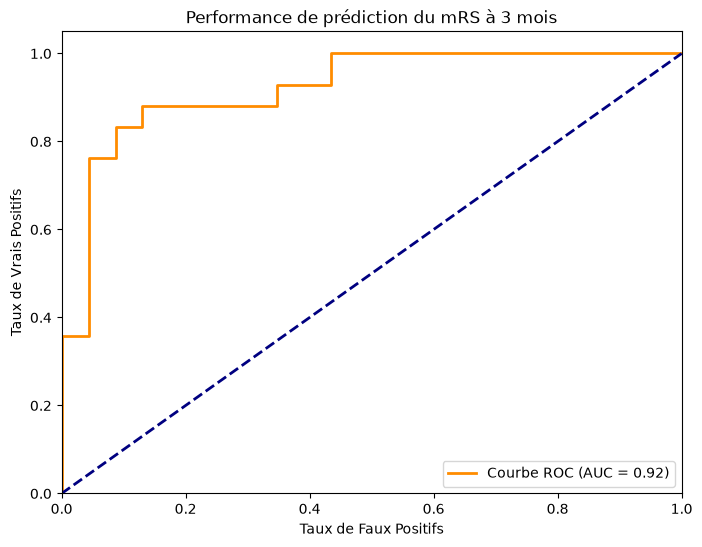

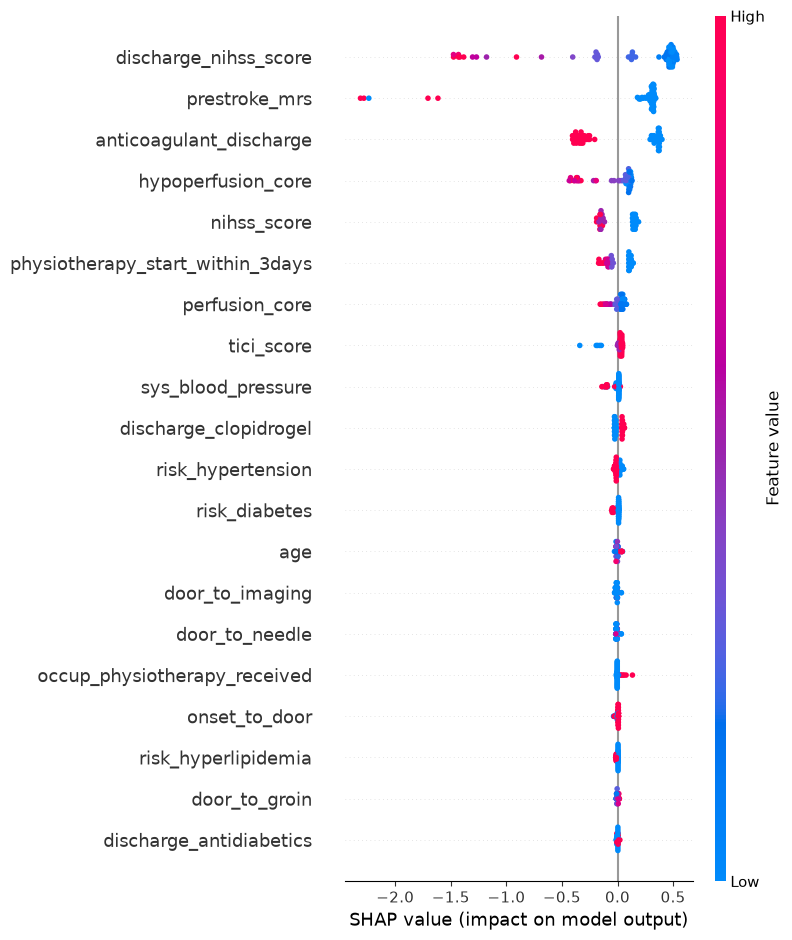

In [23]:
y_pred = best_catboost.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy sur le jeu de test : {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# ==========================================
# COURBE ROC
# ==========================================
# On récupère les probabilités (pas juste 0 ou 1, mais le % de certitude)
y_proba = best_catboost.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Ligne du hasard
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Performance de prédiction du mRS à 3 mois')
plt.legend(loc="lower right")
plt.show()

# ==========================================
# SHAP
# ==========================================
explainer = shap.TreeExplainer(best_catboost)
shap_values = explainer.shap_values(X_test)

# Affichage du Summary Plot
shap.summary_plot(shap_values, X_test)